In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from qubic.lib.Qdictionary import qubicDict
from qubic.lib.Instrument.Qacquisition import QubicMultiAcquisitions
from qubic.lib.Qsamplings import get_pointing, equ2gal
from qubic.lib.MapMaking.FrequencyMapMaking.Qspectra_component import CMBModel

%matplotlib inline

In [2]:
nside = 256

# Initialize QUBIC instance

Build the QUBIC dictionary, mandatory to use the QUBIC functions

In [3]:
# Build MPI communicator and qubic dict
dictfilename = 'qubic/qubic/dicts/pipeline_demo.dict'
d = qubicDict()
d.read_from_file(dictfilename)

center = equ2gal(d['RA_center'], d['DEC_center'])

d['nf_recon'] = 2
d['MultiBand'] = True
d['nside'] = nside

d['npointings'] = 100
d['synthbeam_kmax'] = 1
nf_sub = d['nf_sub']
d['synthbeam_fraction'] = 1

d['noiseless'] = True
d['photon_noise'] = False
d['use_synthbeam_fits_file'] = False

In [4]:
d["interp_projection"] = True

In [5]:
# Build scanning strategy
sampling = get_pointing(d)

In [6]:
# Number of sub-acquisitions
nsub_max = 124
nsub_list = np.arange(4, nsub_max + 1, 10)

In [ ]:
TOD_list = []
freq_list = []
maps_list = []

np.random.seed(d['seed'])

# Build CMB map
cl_cmb = CMBModel(None).give_cl_cmb(r=0, Alens=1)
cmb_map = hp.synfast(cl_cmb, nside, new=True, verbose=False).T

for insub in nsub_list:
    print(f"Processing {insub} sub-acquisitions")
    input_maps = np.ones((insub, hp.nside2npix(nside), 3)) * cmb_map[None, ...]
    
    # Build acquisition operator
    Qacq = QubicMultiAcquisitions(d, insub, 2, sampling=sampling)
    
    # Build TOD
    tod = []
    map_list = []
    for i in range(insub):
        tod.append(Qacq.H[i](input_maps[i]))
        map_list.append(Qacq.H[i].T(tod[-1]))

    TOD_list.append(np.sum(tod, axis=0, dtype=np.float64))
    maps_list.append(np.mean(map_list, axis=0))
    freq_list.append(np.array(Qacq.allnus))

Processing 4 sub-acquisitions
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (99200,9) elements = 13.623046875 MiB in 

In [ ]:
print(tod[0].dtype)
print(tod[0][0])

float64
[ 5.86431912e-21  3.10878117e-20  2.60439897e-20  2.06080231e-20
 -1.95900882e-21 -2.37520670e-20  1.89007362e-20  4.35732964e-20
  1.14746376e-21  8.75361827e-21  3.80457531e-21  2.11885508e-21
 -5.16564334e-22  1.19915507e-20 -2.84749557e-21  2.87512969e-20
  5.89706638e-21  4.79700322e-21  1.99741693e-20  1.32700965e-20
  2.49104770e-21 -1.88198875e-21 -1.07772394e-20  6.80556724e-21
  3.73508118e-20  4.28260273e-21 -1.48726403e-20  1.76240658e-20
  5.30431682e-21  1.11918898e-21  2.06604240e-20 -2.20252923e-20
  1.07955726e-20 -1.41470191e-20  3.50744986e-20 -3.28476726e-21
  9.69151940e-21 -1.77513853e-20  3.11465606e-22  6.01162673e-21
  1.47330281e-22  7.82799560e-21 -1.03488684e-20 -2.84433685e-21
 -4.57026836e-21  9.21489238e-21 -8.76932625e-22 -4.33914823e-21
 -8.41295347e-21 -1.63830652e-20 -2.80715355e-22 -1.95253884e-21
 -4.68112797e-21 -2.26907581e-20 -1.51735037e-20  1.72441760e-20
 -1.18041465e-20  9.61484467e-21  8.98061652e-21  3.71544459e-20
  8.10965177e-21 

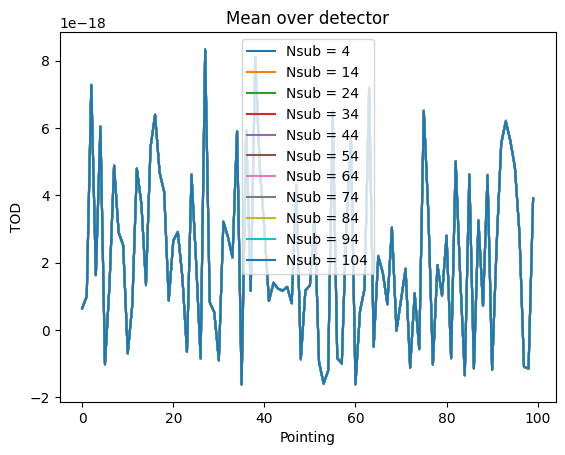

In [ ]:
for i in range(nsub_list.size):
    plt.plot(np.mean(TOD_list[i], axis=0), label=f"Nsub = {nsub_list[i]}")

plt.title("Mean over detector")
plt.xlabel("Pointing")
plt.ylabel("TOD")
plt.legend(loc='best')

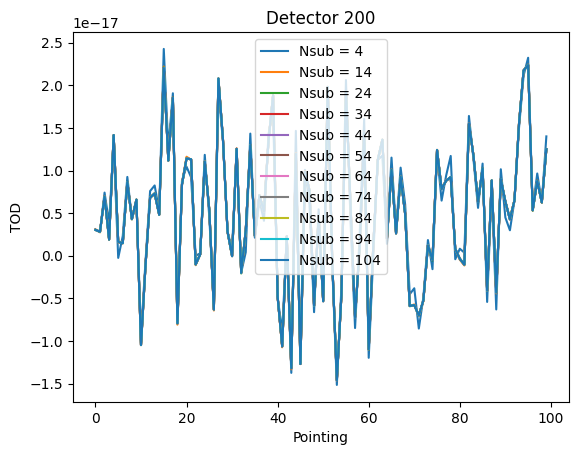

In [ ]:
det_index = 200

for i in range(nsub_list.size):
    plt.plot(TOD_list[i][det_index], label=f"Nsub = {nsub_list[i]}")

plt.title(f"Detector {det_index}")
plt.xlabel("Pointing")
plt.ylabel("TOD")
plt.legend(loc='best')

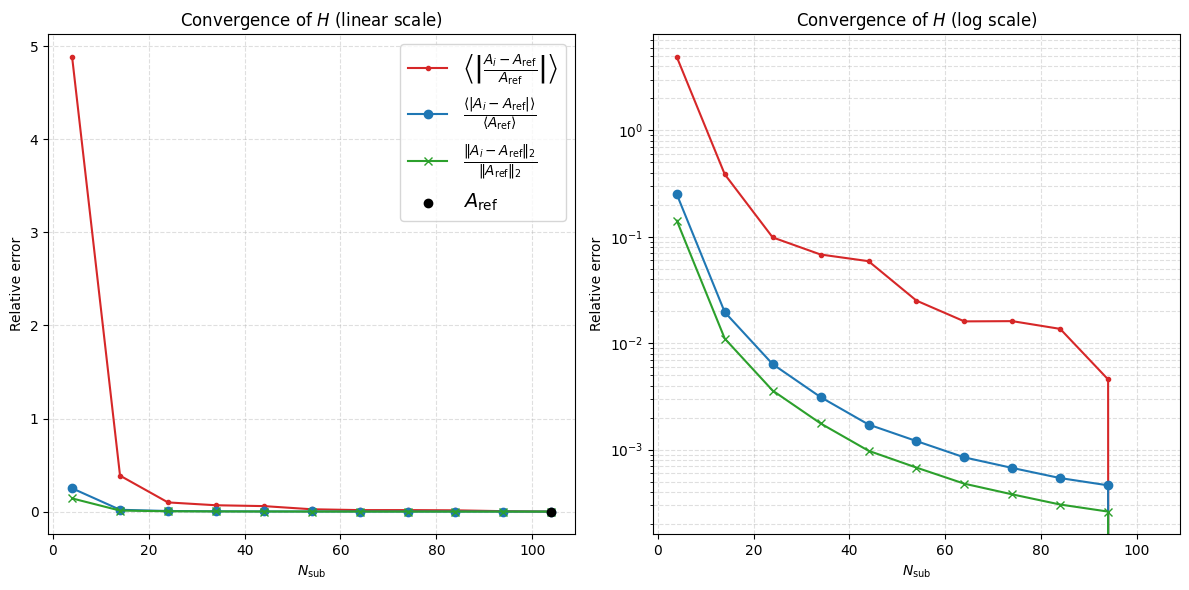

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

A_ref = TOD_list[-1]

# Stockage pour tracer en une fois (plus propre visuellement)
rel_errors = []
rel_errors_mean = []
rel_errors_norm = []

for i in range(len(TOD_list)):
    A_i = TOD_list[i]

    rel_errors.append(np.mean(np.abs((A_i - A_ref) / A_ref)))
    rel_errors_mean.append(np.mean(np.abs(A_i - A_ref)) / np.mean(A_ref))
    rel_errors_norm.append(np.linalg.norm(A_i - A_ref) / np.linalg.norm(A_ref))

# Conversion en arrays
rel_errors = np.array(rel_errors)
rel_errors_mean = np.array(rel_errors_mean)
rel_errors_norm = np.array(rel_errors_norm)

# --- Plot ---
for ax in (ax1, ax2):
    ax.plot(nsub_list, rel_errors, '.-', color='tab:red',
            label=r'$\left\langle \left|\frac{A_i - A_{\mathrm{ref}}}{A_{\mathrm{ref}}}\right| \right\rangle$')

    ax.plot(nsub_list, rel_errors_mean, 'o-', color='tab:blue',
            label=r'$\frac{\langle |A_i - A_{\mathrm{ref}}| \rangle}{\langle A_{\mathrm{ref}} \rangle}$')

    ax.plot(nsub_list, rel_errors_norm, 'x-', color='tab:green',
            label=r'$\frac{\|A_i - A_{\mathrm{ref}}\|_2}{\|A_{\mathrm{ref}}\|_2}$')

    ax.set_xlabel(r'$N_{\mathrm{sub}}$')
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

# Labels et titres
ax1.set_ylabel(r'Relative error')
ax1.set_title(r'Convergence of $H$ (linear scale)')
ax1.scatter(nsub_list[-1], 0, color='black', zorder=5,
            label=r'$A_{\mathrm{ref}}$')

ax2.set_ylabel(r'Relative error')
ax2.set_title(r'Convergence of $H$ (log scale)')
ax2.set_yscale('log')
ax2.scatter(nsub_list[-1], 0, color='black', zorder=5,
            label=r'$A_{\mathrm{ref}}$')

# Légende unique (évite duplication)
ax1.legend(loc='best', fontsize=14)

plt.tight_layout()

In [ ]:
print(TOD_list[-1].shape)

(992, 100)


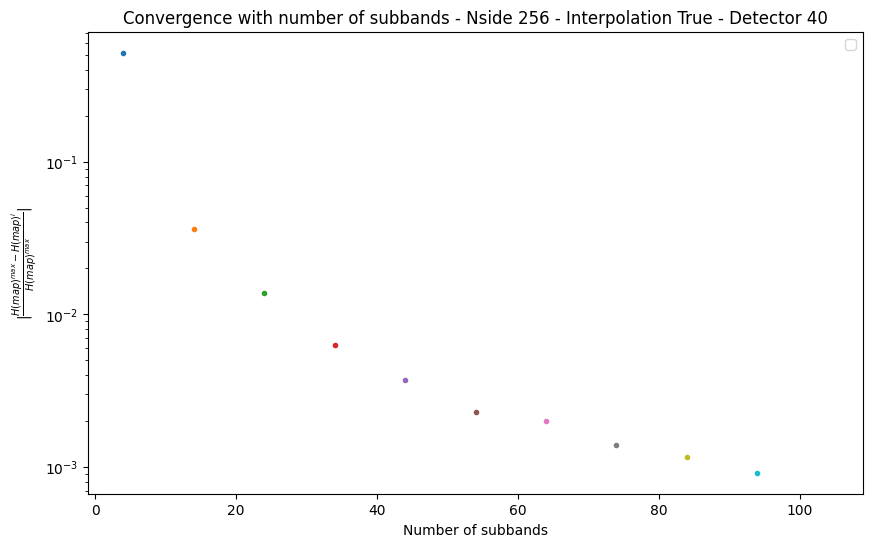

In [ ]:
plt.figure(figsize=(10,6))
idet = 40
for i in range(len(TOD_list)):
    rel_error = np.mean(np.abs((TOD_list[-1][idet] - TOD_list[i][idet]) / TOD_list[-1][idet]))
    
    plt.plot(nsub_list[i], rel_error, '.')
plt.xlabel('Number of subbands')
plt.ylabel(r'|$\frac{H(map)^{max} - H(map)^{i}}{H(map)^{max}}$|')
plt.yscale('log')
plt.legend()
plt.title(f'Convergence with number of subbands - Nside {nside} - Interpolation {d["interp_projection"]} - Detector {idet}')
plt.show()

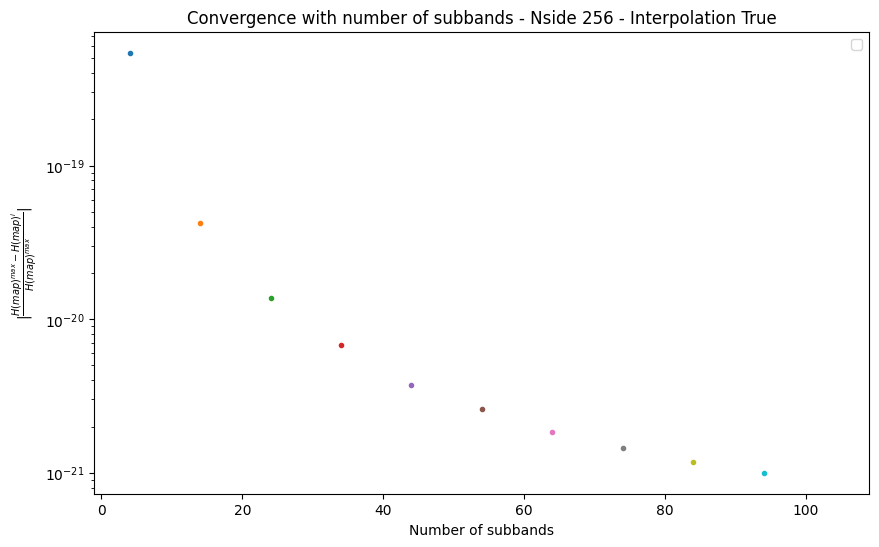

In [ ]:
plt.figure(figsize=(10,6))
for i in range(len(TOD_list)):
    rel_error = np.mean(np.abs((TOD_list[-1] - TOD_list[i]) / TOD_list[-1]))
    
    plt.plot(nsub_list[i], rel_error, '.')
plt.xlabel('Number of subbands')
plt.ylabel(r'|$\frac{H(map)^{max} - H(map)^{i}}{H(map)^{max}}$|')
plt.yscale('log')
plt.legend()
plt.title(f'Convergence with number of subbands - Nside {nside} - Interpolation {d["interp_projection"]}')
plt.show()

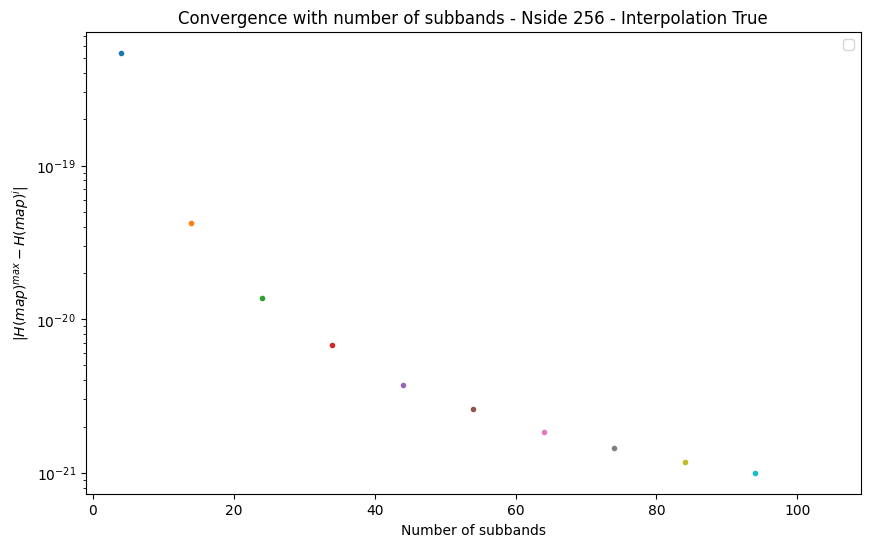

In [ ]:
plt.figure(figsize=(10,6))
for i in range(len(TOD_list)):
    rel_error = np.mean(np.abs((TOD_list[-1] - TOD_list[i]) ))
    
    plt.plot(nsub_list[i], rel_error, '.')
plt.xlabel('Number of subbands')
plt.ylabel(r'|$H(map)^{max} - H(map)^{i}$|')
plt.yscale('log')
plt.legend()
plt.title(f'Convergence with number of subbands - Nside {nside} - Interpolation {d["interp_projection"]}')
plt.show()

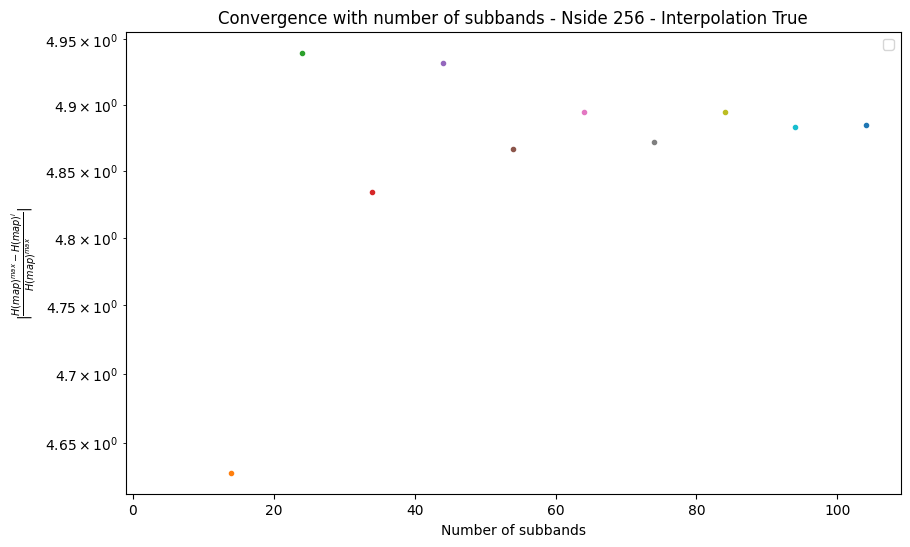

In [ ]:
plt.figure(figsize=(10,6))
for i in range(len(TOD_list)):
    rel_error = np.mean(np.abs((TOD_list[0] - TOD_list[i]) / TOD_list[-1]))
    
    plt.plot(nsub_list[i], rel_error, '.')
plt.xlabel('Number of subbands')
plt.ylabel(r'|$\frac{H(map)^{max} - H(map)^{i}}{H(map)^{max}}$|')
plt.yscale('log')
plt.legend()
plt.title(f'Convergence with number of subbands - Nside {nside} - Interpolation {d["interp_projection"]}')
plt.show()